Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from typing import Tuple
from IPython.display import display, clear_output

Load and visualize dataset

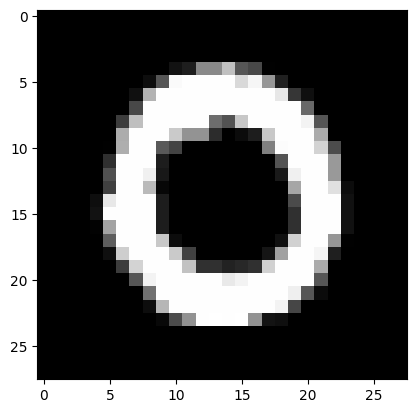

In [2]:
#Load data
train_data = pd.read_csv('Train.csv')

#Split data and labels
X = train_data.iloc[:, 1:]  
y = train_data.iloc[:, 0]

#Process data
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)  
X = X.values / 255.0
X = X.reshape(-1, 28, 28, 1)

#Visualize data as image on chosen index
plt.imshow(X[1].reshape(28, 28), cmap='gray')

ACTIVATION FUNCTION 


USE ReLU Functions to introduce non-linearity for model can do multi-class classification

In [3]:
class ReLU:
    def __init__(self):
        self.cache = None 
    def forward(self, X: np.ndarray) -> np.ndarray:
        self.cache = X 
        # Luu nhung tham so duoc kich hoat de luc truyen GD thi chi truyen cho nhung tham so duoc kich hoat 
        return np.maximum(0, X)
    def backward(self, dout: np.ndarray) -> np.ndarray:
        X = self.cache
        return dout * (X > 0)

SOFTMAX

In [4]:
class Softmax:
    def __init__(self):
        self.cache = None 
    def forward(self, X: np.ndarray) -> np.ndarray:
        exp_X = np.exp(X - np.max(X, axis=1, keepdims=True))
        self.cache = exp_X / np.sum(exp_X, axis=1, keepdims=True)
        return self.cache
    def backward(self, y: np.ndarray) -> np.ndarray:
        return self.cache - y
    def loss(self, y: np.ndarray) -> float:
        probs = self.cache
        #prevent log(0)
        probs = np.clip(probs, 1e-15, 1.0)
        n = probs.shape[0]
        loss = -np.sum(y * np.log(probs)) / n
        return float(loss)

FULLY CONNECTED LAYER (FC)

In [5]:
class Dense:
    def __init__(self, in_features: int, out_features: int):
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros((1, out_features))
        self.dW = None
        self.db = None
        self.cache = None
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        self.cache = X
        return X @ self.W + self.b
    
    def backward(self, dout: np.ndarray) -> np.ndarray:
        X = self.cache
        self.dW = X.T @ dout
        self.db = np.sum(dout, axis=0, keepdims=True)
        return dout @ self.W.T

CONVOLUTION

PARAMETERS:
+ Image  : 3D ARRAY
+ K      : Kernel (or filters) small matrix slide on images pixel 
+ padding: The ammount pixel 
+ stride : jump of the kernel 

In [ ]:
class Conv2D:
    """Convolutional layer using im2col algorithm"""
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, padding: int = 0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        
        # Initialization
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.W = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * scale
        self.b = np.zeros((out_channels, 1))
        
        self.dW = None
        self.db = None
        self.cache = None
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        n, c, h, w = X.shape
        
        if self.padding > 0:
            X_padded = np.pad(X, ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        else:
            X_padded = X
            
        h_out = (h + 2 * self.padding - self.kernel_size) // self.stride + 1
        w_out = (w + 2 * self.padding - self.kernel_size) // self.stride + 1
        
        # 1. Transform Image to Columns
        X_col = self.im2col(X_padded, self.kernel_size, self.stride)
        
        # 2. Reshape Weights: (Out_C, In_C * K * K)
        W_col = self.W.reshape(self.out_channels, -1)
        
        # 3. Matrix Multiplication: (Out_C, N * H_out * W_out)
        out = W_col @ X_col + self.b
        
        # 4. Reshape back to image format: (Out_C, H_out, W_out, N) -> (N, Out_C, H_out, W_out)
        out = out.reshape(self.out_channels, h_out, w_out, n)
        out = out.transpose(3, 0, 1, 2)
        
        self.cache = (X, X_col)
        return out
    
    def backward(self, dout: np.ndarray) -> np.ndarray:
        X, X_col = self.cache
        n, c, h, w = X.shape
        
        # Prepare dout: (Out_C, N * H_out * W_out)
        dout_reshaped = dout.transpose(1, 2, 3, 0).reshape(self.out_channels, -1)
        
        # Gradient w.r.t weights
        self.dW = (dout_reshaped @ X_col.T).reshape(self.W.shape)
        self.db = np.sum(dout_reshaped, axis=1, keepdims=True)
        
        # Gradient w.r.t input column
        W_col = self.W.reshape(self.out_channels, -1)
        dX_col = W_col.T @ dout_reshaped
        
        # Column to Image
        dX = self.col2im(dX_col, X.shape, self.kernel_size, self.stride, self.padding)
        
        return dX
    
    def im2col(self, X: np.ndarray, kernel_size: int, stride: int) -> np.ndarray:
        """
        Transforms input image to column matrix.
        Output shape: (C * K * K, N * H_out * W_out)
        """
        n, c, h, w = X.shape
        h_out = (h - kernel_size) // stride + 1
        w_out = (w - kernel_size) // stride + 1
        
        # Index calculation
        i0 = np.repeat(np.arange(kernel_size), kernel_size)
        i0 = np.tile(i0, c)
        i1 = stride * np.repeat(np.arange(h_out), w_out)
        
        j0 = np.tile(np.arange(kernel_size), kernel_size * c)
        j1 = stride * np.tile(np.arange(w_out), h_out)
        
        i = i0.reshape(-1, 1) + i1.reshape(1, -1)
        j = j0.reshape(-1, 1) + j1.reshape(1, -1)
        
        k = np.repeat(np.arange(c), kernel_size * kernel_size).reshape(-1, 1)
        
        # Get columns: (C*K*K, H_out*W_out, N) -> (C*K*K, N*H_out*W_out)
        # Using advanced indexing. This creates a large temporary array.
        cols = X[:, k, i, j] 
        cols = cols.transpose(1, 2, 0).reshape(c * kernel_size * kernel_size, -1)
        return cols
    
    def col2im(self, cols: np.ndarray, X_shape: Tuple, kernel_size: int, stride: int, padding: int) -> np.ndarray:
        n, c, h, w = X_shape
        h_padded, w_padded = h + 2 * padding, w + 2 * padding
        X_padded = np.zeros((n, c, h_padded, w_padded))
        
        h_out = (h_padded - kernel_size) // stride + 1
        w_out = (w_padded - kernel_size) // stride + 1
        
        i0 = np.repeat(np.arange(kernel_size), kernel_size)
        i0 = np.tile(i0, c)
        i1 = stride * np.repeat(np.arange(h_out), w_out)
        j0 = np.tile(np.arange(kernel_size), kernel_size * c)
        j1 = stride * np.tile(np.arange(w_out), h_out)
        i = i0.reshape(-1, 1) + i1.reshape(1, -1)
        j = j0.reshape(-1, 1) + j1.reshape(1, -1)
        k = np.repeat(np.arange(c), kernel_size * kernel_size).reshape(-1, 1)
        
        cols_reshaped = cols.reshape(c * kernel_size * kernel_size, -1, n)
        cols_reshaped = cols_reshaped.transpose(2, 0, 1)
        
        # Vectorized accumulation using add.at
        # Slice(None) corresponds to 'n' dimension
        np.add.at(X_padded, (slice(None), k, i, j), cols_reshaped)
        
        if padding > 0:
            return X_padded[:, :, padding:-padding, padding:-padding]
        return X_padded

POOLING

In [7]:
class MaxPool2D:
    """Max Pooling layer with forward and backward pass"""
    def __init__(self, kernel_size: int = 2, stride: int = 2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.cache = None
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        n, c, h, w = X.shape
        k, s = self.kernel_size, self.stride
        
        h_out = (h - k) // s + 1
        w_out = (w - k) // s + 1
        
        output = np.zeros((n, c, h_out, w_out))
        
        for i in range(h_out):
            for j in range(w_out):
                h_start, h_end = i * s, i * s + k
                w_start, w_end = j * s, j * s + k
                window = X[:, :, h_start:h_end, w_start:w_end]
                output[:, :, i, j] = np.max(window, axis=(2, 3))
        
        self.cache = X
        return output
    
    def backward(self, dout: np.ndarray) -> np.ndarray:
        X = self.cache
        n, c, h, w = X.shape
        k, s = self.kernel_size, self.stride
        
        h_out = (h - k) // s + 1
        w_out = (w - k) // s + 1
        
        dX = np.zeros_like(X)
        
        for i in range(h_out):
            for j in range(w_out):
                h_start, h_end = i * s, i * s + k
                w_start, w_end = j * s, j * s + k
                window = X[:, :, h_start:h_end, w_start:w_end]
                
                # Create mask for max values
                max_vals = np.max(window, axis=(2, 3), keepdims=True)
                mask = (window == max_vals)
                
                # Distribute gradient to max positions
                dX[:, :, h_start:h_end, w_start:w_end] += mask * dout[:, :, i:i+1, j:j+1]
        
        return dX



FLATTENING

In [8]:
class Flatten:
    def __init__(self):
        self.cache = None
    def forward(self, X: np.ndarray) -> np.ndarray:
        self.cache = X.shape
        return X.reshape(X.shape[0], -1)
    def backward(self, dout: np.ndarray) -> np.ndarray:
        return dout.reshape(self.cache)

MODEL LAYOUT
- Input : images (resolution of 28 x 28 and monochromatic) of hand written digits
- Block 1
    + Conv2D (1)
    + Activation (1)
    + Max Pooling (1)
- Flatten
- Block 2
    + Fully Connected (1)
    + Activation (2)
- Fully Connected
- Softmax

MODEL SETUP 

Convolutional Neural Network for MNIST digit classification (1 Block Model)
Architecture:
- Conv2D (1->8 filters, 3x3) -> ReLU -> MaxPool (2x2)
- Flatten -> Dense (1568->64) -> ReLU -> Dense (64->10) -> Softmax

In [ ]:
# ==================== CNN MODEL CLASS ====================
class CNN:
    def __init__(self):
        # Block 1: Conv -> ReLU -> MaxPool
        self.conv1 = Conv2D(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(kernel_size=2, stride=2)
        
        # Flatten
        self.flatten = Flatten()
        
        # Block 2: Dense -> ReLU
        # After 1 pooling layer: 28x28 -> 14x14, with 8 channels = 8*14*14 = 1568
        self.fc1 = Dense(in_features=8*14*14, out_features=64)
        self.relu2 = ReLU()
        
        # Output layer
        self.fc2 = Dense(in_features=64, out_features=10)
        self.softmax = Softmax()
        
        # Store all layers with trainable parameters
        self.trainable_layers = [self.conv1, self.fc1, self.fc2]
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        """Forward pass through the network"""
        # Block 1
        out = self.conv1.forward(X)
        out = self.relu1.forward(out)
        out = self.pool1.forward(out)
        
        # Flatten and Dense layers
        out = self.flatten.forward(out)
        out = self.fc1.forward(out)
        out = self.relu2.forward(out)
        out = self.fc2.forward(out)
        out = self.softmax.forward(out)
        
        return out
    
    def backward(self, y_true: np.ndarray) -> None:
        """Backward pass through the network"""
        # Softmax + Cross-entropy gradient
        dout = self.softmax.backward(y_true)
        
        # Dense layers backward
        dout = self.fc2.backward(dout)
        dout = self.relu2.backward(dout)
        dout = self.fc1.backward(dout)
        
        # Flatten backward
        dout = self.flatten.backward(dout)
        
        # Block 1 backward
        dout = self.pool1.backward(dout)
        dout = self.relu1.backward(dout)
        dout = self.conv1.backward(dout)
    
    def update_params(self, learning_rate: float) -> None:
        """Update weights using SGD"""
        for layer in self.trainable_layers:
            layer.W -= learning_rate * layer.dW
            layer.b -= learning_rate * layer.db
    
    def loss(self, y_true: np.ndarray) -> float:
        """Calculate cross-entropy loss"""
        return self.softmax.loss(y_true)

TRAINING FUNCTION 

Args:

model: CNN model instance

X_train: Training images (N, C, H, W)

y_train: Training labels (one-hot encoded)

X_val: Validation images

y_val: Validation labels

epochs: Number of training epochs

batch_size: Mini-batch size

learning_rate: Learning rate for SGD


In [10]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=32, learning_rate=0.01):
    n_samples = X_train.shape[0]
    n_batches = n_samples // batch_size
    
    train_losses = []
    train_accuracies = []   # Thêm training accuracy
    val_accuracies = []
    
    for epoch in range(epochs):
        # Shuffle training data
        indices = np.random.permutation(n_samples)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_loss = 0.0
        epoch_correct = 0   # Đếm số dự đoán đúng
        epoch_total = 0     # Tổng số samples
        
        for batch_idx in range(n_batches):
            # Get mini-batch
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]
            
            # Forward pass
            predictions = model.forward(X_batch)
            
            # Calculate loss
            batch_loss = model.loss(y_batch)
            epoch_loss += batch_loss
            
            # Calculate training accuracy cho batch này
            pred_labels = np.argmax(predictions, axis=1)
            true_labels = np.argmax(y_batch, axis=1)
            epoch_correct += np.sum(pred_labels == true_labels)
            epoch_total += len(y_batch)
            
            # Backward pass
            model.backward(y_batch)
            
            # Update parameters
            model.update_params(learning_rate)
            
            # Print progress
            if (batch_idx + 1) % 100 == 0:
                print(f"  Batch {batch_idx + 1}/{n_batches}, Loss: {batch_loss:.4f}")
        
        # Calculate average loss for epoch
        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        
        # Training accuracy cho epoch
        train_accuracy = epoch_correct / epoch_total
        train_accuracies.append(train_accuracy)
        
        # Validation accuracy
        val_pred = model.forward(X_val)
        val_pred_labels = np.argmax(val_pred, axis=1)
        val_true_labels = np.argmax(y_val, axis=1)
        val_accuracy = np.mean(val_pred_labels == val_true_labels)
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f} - Train Acc: {train_accuracy*100:.2f}% - Val Acc: {val_accuracy * 100:.2f}%")
    
    return train_losses, train_accuracies, val_accuracies


DATA PREPARATION

In [11]:
# Reshape data from (N, H, W, 1) to (N, 1, H, W) for Conv2D
X_reshaped = X.transpose(0, 3, 1, 2)  # (N, 1, 28, 28)

# One-hot encode labels
num_classes = 10
y_onehot = np.zeros((len(y), num_classes))
y_onehot[np.arange(len(y)), y] = 1

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_reshaped, y_onehot, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Validation labels shape: {y_val.shape}")


Training set shape: (33600, 1, 28, 28)
Validation set shape: (8400, 1, 28, 28)
Training labels shape: (33600, 10)
Validation labels shape: (8400, 10)


INITIALIZE AND TRAIN MODEL

In [12]:
# Create model
model = CNN()

# Train the model
print("Starting Training...")

train_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=10,           
    batch_size=32,      
    learning_rate=0.005  
)

Starting Training...
  Batch 100/1050, Loss: 0.8754
  Batch 200/1050, Loss: 0.4816
  Batch 300/1050, Loss: 0.0693
  Batch 400/1050, Loss: 0.1831
  Batch 500/1050, Loss: 0.1965
  Batch 600/1050, Loss: 0.0489
  Batch 700/1050, Loss: 0.1106
  Batch 800/1050, Loss: 0.0140
  Batch 900/1050, Loss: 0.0352
  Batch 1000/1050, Loss: 0.1286
Epoch 1/10 - Loss: 0.2153 - Train Acc: 93.12% - Val Acc: 97.55%
  Batch 100/1050, Loss: 0.0457
  Batch 200/1050, Loss: 0.0334
  Batch 300/1050, Loss: 0.1252
  Batch 400/1050, Loss: 0.0570
  Batch 500/1050, Loss: 0.0784
  Batch 600/1050, Loss: 0.0369
  Batch 700/1050, Loss: 0.0202
  Batch 800/1050, Loss: 0.0244
  Batch 900/1050, Loss: 0.0847
  Batch 1000/1050, Loss: 0.0026
Epoch 2/10 - Loss: 0.0731 - Train Acc: 97.69% - Val Acc: 98.01%
  Batch 100/1050, Loss: 0.0081
  Batch 200/1050, Loss: 0.2187
  Batch 300/1050, Loss: 0.1489
  Batch 400/1050, Loss: 0.0343
  Batch 500/1050, Loss: 0.0124
  Batch 600/1050, Loss: 0.2196
  Batch 700/1050, Loss: 0.2032
  Batch 800/

PLOT TRAINING RESULTS

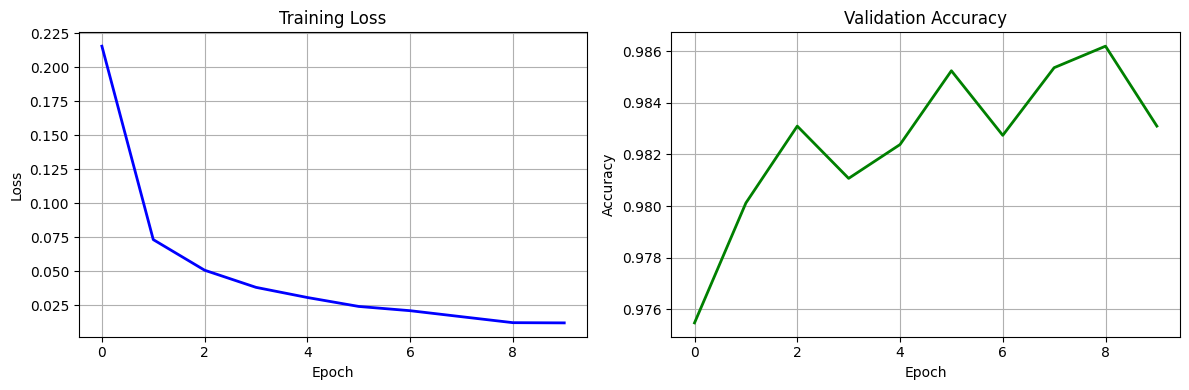


Final Validation Accuracy: 98.31%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot training loss
axes[0].plot(train_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# Plot validation accuracy
axes[1].plot(val_accuracies, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Validation Accuracy: {val_accuracies[-1] * 100:.2f}%")


EVALUATE - Biểu đồ Training Accuracy & Validation Accuracy

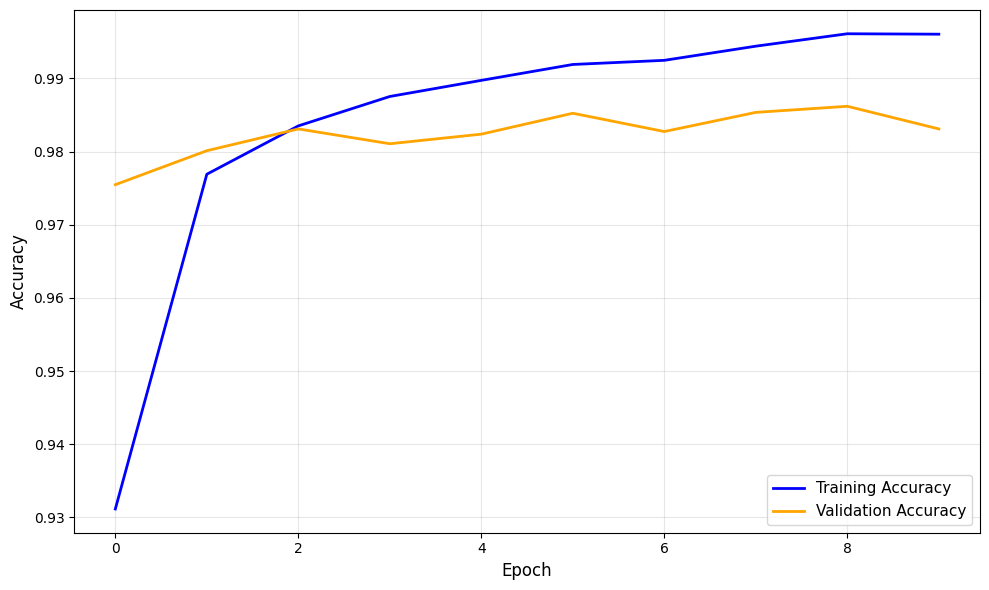

Test Accuracy: 98.31%


In [14]:
def plot_training_results(train_accuracies, val_accuracies):
    
    plt.figure(figsize=(10, 6))
    
    epochs = range(len(train_accuracies))
    
    # Vẽ Training Accuracy (màu xanh dương)
    plt.plot(epochs, train_accuracies, 'b-', linewidth=2, label='Training Accuracy')
    
    # Vẽ Validation Accuracy (màu cam)
    plt.plot(epochs, val_accuracies, color='orange', linewidth=2, label='Validation Accuracy')
    
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Đánh giá
plot_training_results(train_accuracies, val_accuracies)

# Test accuracy (sử dụng validation set làm test set)
test_pred = model.forward(X_val)
test_pred_labels = np.argmax(test_pred, axis=1)
test_true_labels = np.argmax(y_val, axis=1)
test_accuracy = np.mean(test_pred_labels == test_true_labels)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

FEATURE MAP VISUALIZATION

 FEATURE MAP VISUALIZATION
Sample Index: 58



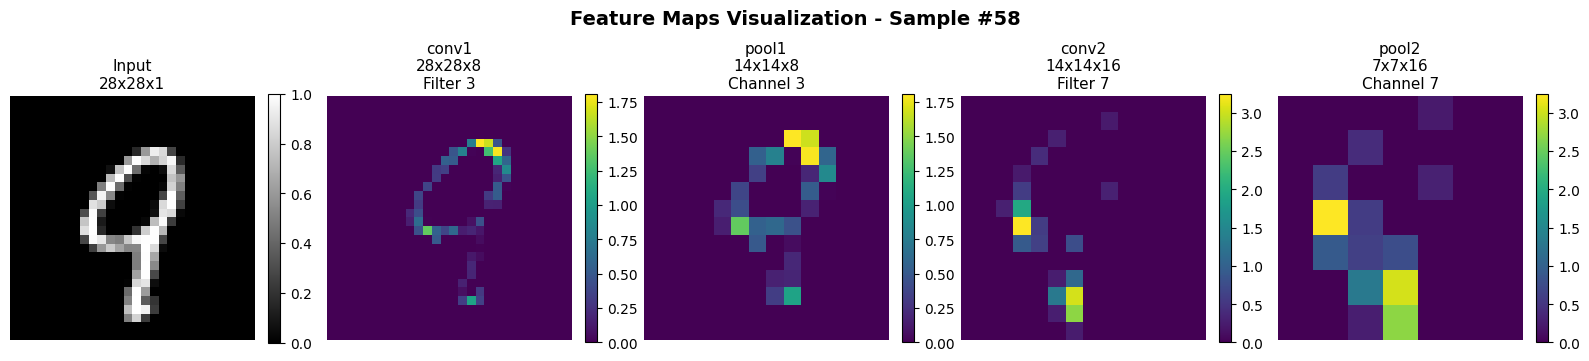

Layer Information:
  Input:  28x28x1
  Conv1:  28x28x8  (8 filters, 3x3, padding=1)
  Pool1:  14x14x8  (MaxPool 2x2)
  Conv2:  14x14x16  (16 filters, 3x3, padding=1)
  Pool2:  7x7x16  (MaxPool 2x2)

 True Label: 9
 Predicted:  9 (Confidence: 100.0%)


In [ ]:
def visualize_feature_maps(model, image, image_idx=0):
    """
    Hiển thị feature maps sau mỗi lớp xử lý của CNN
    Tương tự như: Input -> Conv1 -> Pool1
    """
    # Đảm bảo image có shape đúng (1, 1, 28, 28)
    if len(image.shape) == 3:
        image = image.reshape(1, *image.shape)
    if image.shape[1] != 1:  # Nếu shape là (N, H, W, C)
        image = image.transpose(0, 3, 1, 2)
    
    # Forward qua từng lớp và lưu kết quả
    # Input
    input_img = image[0, 0]  # (28, 28)
    
    # Conv1 + ReLU
    conv1_out = model.conv1.forward(image)
    relu1_out = model.relu1.forward(conv1_out)
    
    # Pool1
    pool1_out = model.pool1.forward(relu1_out)
    
    # Lấy shape
    _, c1, h1, w1 = relu1_out.shape  # Conv1: (1, 8, 28, 28)
    _, c2, h2, w2 = pool1_out.shape  # Pool1: (1, 8, 14, 14)
    
    # Chọn filter/channel để hiển thị
    filter1 = min(3, c1-1)   # Filter của Conv1
    
    # Tạo figure với 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # 1. Input Image
    im0 = axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title(f'Input\n{input_img.shape[0]}x{input_img.shape[1]}x1', fontsize=11)
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # 2. Conv1 + ReLU output (chọn 1 filter)
    conv1_feature = relu1_out[0, filter1]  # (28, 28)
    im1 = axes[1].imshow(conv1_feature, cmap='viridis')
    axes[1].set_title(f'conv1\n{h1}x{w1}x{c1}\nFilter {filter1}', fontsize=11)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # 3. Pool1 output
    pool1_feature = pool1_out[0, filter1]  # (14, 14)
    im2 = axes[2].imshow(pool1_feature, cmap='viridis')
    axes[2].set_title(f'pool1\n{h2}x{w2}x{c2}\nChannel {filter1}', fontsize=11)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    plt.suptitle(f'Feature Maps Visualization (1 Block Model) - Sample #{image_idx}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # In thông tin chi tiết
    print(f"Layer Information:")
    print(f"  Input:  {input_img.shape[0]}x{input_img.shape[1]}x1")
    print(f"  Conv1:  {h1}x{w1}x{c1}  (8 filters, 3x3, padding=1)")
    print(f"  Pool1:  {h2}x{w2}x{c2}  (MaxPool 2x2)")


# Sample này sẽ được dùng chung cho cả FEATURE MAP và PROBABILITY DISTRIBUTION
SAMPLE_IDX = 58

print(" FEATURE MAP VISUALIZATION")
print(f"Sample Index: {SAMPLE_IDX}\n")

# Lấy ảnh mẫu
sample_image = X_val[SAMPLE_IDX:SAMPLE_IDX+1]  # Shape: (1, 1, 28, 28)

# Hiển thị feature maps (sử dụng model từ cell INITIALIZE AND TRAIN MODEL)
visualize_feature_maps(model, sample_image, image_idx=SAMPLE_IDX)

# Dự đoán kết quả
prediction = model.forward(sample_image)
predicted_digit = np.argmax(prediction)
true_digit = np.argmax(y_val[SAMPLE_IDX])
confidence = prediction[0, predicted_digit] * 100

print(f"\n True Label: {true_digit}")
print(f" Predicted:  {predicted_digit} (Confidence: {confidence:.1f}%)")

SOFTMAX PROBABILITY DISTRIBUTION VISUALIZATION
Sample Index: 7 (cùng sample với Feature Map)



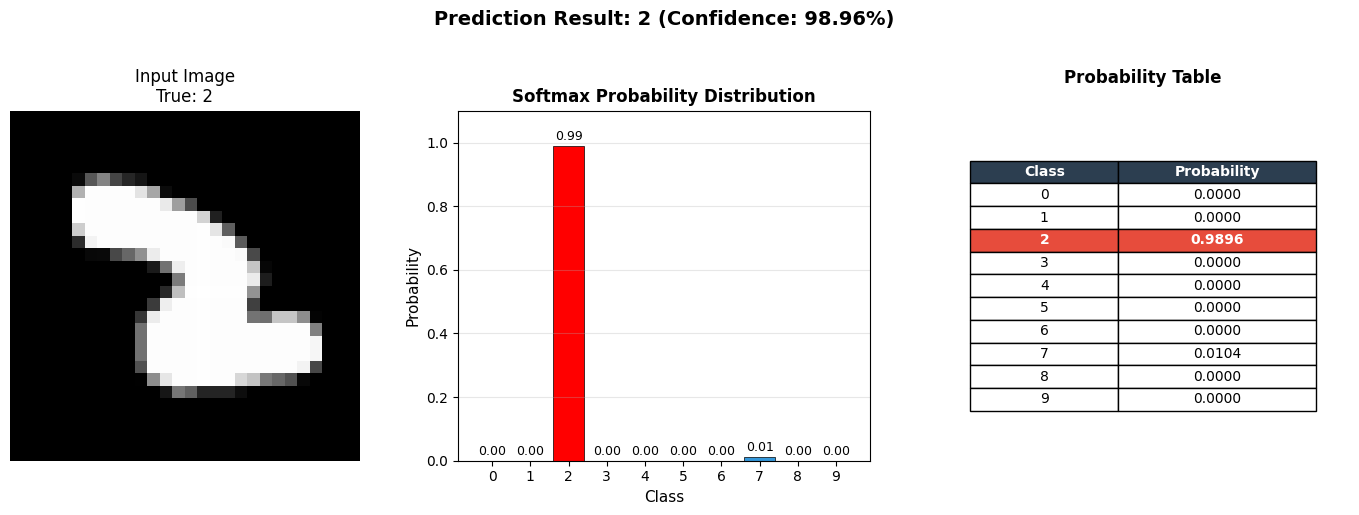

  PREDICTION SUMMARY
  Predicted Class: 2
  Confidence:      98.96%
  True Label:      2
  Status:          CORRECT


(np.int64(2),
 array([1.70284808e-10, 1.45709613e-08, 9.89631660e-01, 9.73994639e-06,
        6.74309977e-14, 1.97816539e-16, 3.24632873e-13, 1.03585858e-02,
        1.53774590e-11, 4.33564351e-16]))

In [16]:
def visualize_prediction(model, image, true_label=None, image_idx=0):
    """
    Hiển thị kết quả dự đoán dưới dạng biểu đồ phân bố xác suất (Softmax output)
    Bao gồm: Biểu đồ cột + Bảng xác suất chi tiết
    """
    # Đảm bảo image có shape đúng
    if len(image.shape) == 3:
        image = image.reshape(1, *image.shape)
    if image.shape[1] != 1:
        image = image.transpose(0, 3, 1, 2)
    
    # Forward pass để lấy xác suất (softmax output)
    probabilities = model.forward(image)[0]  # Shape: (10,)
    predicted_class = np.argmax(probabilities)
    
    # Tạo figure với 3 phần: Ảnh gốc, Biểu đồ, Bảng
    fig = plt.figure(figsize=(14, 5))
    
    # 1. Hiển thị ảnh gốc 
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(image[0, 0], cmap='gray')
    ax1.set_title(f'Input Image\nTrue: {true_label if true_label is not None else "?"}', fontsize=12)
    ax1.axis('off')
    
    # 2. Biểu đồ phân bố xác suất 
    ax2 = fig.add_subplot(1, 3, 2)
    classes = np.arange(10)
    colors = ['red' if i == predicted_class else '#3498db' for i in classes]
    
    bars = ax2.bar(classes, probabilities, color=colors, edgecolor='black', linewidth=0.5)
    
    # Thêm giá trị trên mỗi cột
    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{prob:.2f}', ha='center', va='bottom', fontsize=9)
    
    ax2.set_xlabel('Class', fontsize=11)
    ax2.set_ylabel('Probability', fontsize=11)
    ax2.set_title('Softmax Probability Distribution', fontsize=12, fontweight='bold')
    ax2.set_xticks(classes)
    ax2.set_ylim([0, 1.1])
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Bảng xác suất chi tiết 
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axis('off')
    
    # Tạo dữ liệu bảng
    table_data = [[str(i), f'{probabilities[i]:.4f}'] for i in range(10)]
    
    # Tạo bảng
    table = ax3.table(
        cellText=table_data,
        colLabels=['Class', 'Probability'],
        cellLoc='center',
        loc='center',
        colWidths=[0.3, 0.4]
    )
    
    # Style bảng
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Highlight predicted class row
    for i in range(11):  # 10 rows + 1 header
        if i == 0:  # Header
            table[(i, 0)].set_facecolor('#2c3e50')
            table[(i, 1)].set_facecolor('#2c3e50')
            table[(i, 0)].set_text_props(color='white', fontweight='bold')
            table[(i, 1)].set_text_props(color='white', fontweight='bold')
        elif i - 1 == predicted_class:  # Predicted class row
            table[(i, 0)].set_facecolor('#e74c3c')
            table[(i, 1)].set_facecolor('#e74c3c')
            table[(i, 0)].set_text_props(color='white', fontweight='bold')
            table[(i, 1)].set_text_props(color='white', fontweight='bold')
    
    ax3.set_title('Probability Table', fontsize=12, fontweight='bold', pad=20)
    
    plt.suptitle(f'Prediction Result: {predicted_class} (Confidence: {probabilities[predicted_class]*100:.2f}%)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # In kết quả
    print(f"  PREDICTION SUMMARY")
    print(f"  Predicted Class: {predicted_class}")
    print(f"  Confidence:      {probabilities[predicted_class]*100:.2f}%")
    if true_label is not None:
        status = "CORRECT" if predicted_class == true_label else "WRONG"
        print(f"  True Label:      {true_label}")
        print(f"  Status:          {status}")
    return predicted_class, probabilities


# Sử dụng cùng SAMPLE_IDX từ cell FEATURE MAP
print("SOFTMAX PROBABILITY DISTRIBUTION VISUALIZATION")
print(f"Sample Index: {SAMPLE_IDX} (cùng sample với Feature Map)\n")

# Lấy cùng sample image
sample_image = X_val[SAMPLE_IDX:SAMPLE_IDX+1]
true_label = np.argmax(y_val[SAMPLE_IDX])

# Visualize với model đã train
visualize_prediction(model, sample_image, true_label, SAMPLE_IDX)
